In [1]:
###-----------------
### Import libraries
###-----------------
from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import mean_squared_error  # Import function to calculate various metric

from collections.abc import Callable  # Type hinting callable objects/functions
from typing import Literal  # Literal type hints to restrict variable values

from sklearn.preprocessing import StandardScaler  # Import for standardizing features (zero mean, unit variance)
import tensorflow as tf
from utils.helper import fn_plot_tf_hist # Custom utility

Regression

ANN (feedforward network) works well on classification but not much on regression because regression requires exact values and not probabilities

In [2]:
###----------------------
### Some basic parameters
###----------------------

# inpDir = Path('..') / '..' / 'input'
# outDir = Path('..') / 'output'
# modelDir = Path('..') / 'models'
# subDir = 'fifa_2019'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(seed = RANDOM_STATE) # Set Random Seed for reproducible  results
tf.random.set_seed(RANDOM_STATE)

EPOCHS = 101 # number of epochs
BATCH_SIZE = 16
ALPHA = 0.001 # learning rate
TEST_SIZE = 0.2
TRAIN_SIZE = 566 * BATCH_SIZE

# parameters for Matplotlib
params = {'legend.fontsize': 'x-large',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'x-large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'x-large',
          'ytick.labelsize':'x-large'
         }

plt.rcParams.update(params)

CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [3]:
EPOCHS = 100 # number of epochs
ALPHA = 0.001 # learning rate
BATCH_SIZE = 16 # mini batch size (number of rows)
TRAIN_SIZE = int(18 * BATCH_SIZE)
TEST_SIZE = 0.2
WEIGHT_DECAY = 0.001
PATIENCE = 20
LR_FACTOR = 0.1
LR_PATIENCE = 5
MIN_LR = 1e-6

In [4]:
# creating data
start = -2.1
end = 2.1
delta = 0.001
# training data

X_train = np.arange(start, end+delta, delta)
y_true = 2 * np.square(X_train) + 2 * np.sin(np.pi*X_train)  # y = 2*X + 2*sin(pi*X)
y_rng = np.random.rand(X_train.shape[0]) - 0.5   # generates random error between -0.5 and 0.5
y_train = y_true + y_rng

# testing data
X_test = np.arange(start, end+delta, delta*10)
y_true_test = 2 * np.square(X_test) + 2 * np.sin(np.pi*X_test)  # y = 2*X + 2*sin(pi*X)
y_rng_test = np.random.rand(X_test.shape[0]) - 0.5   # generates random error between -0.5 and 0.5
y_test = y_true_test + y_rng_test * 2


In [5]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4201,), (421,), (4201,), (421,))

In [6]:
X_train.shape[0]/16

262.5625

In [7]:
num_examples = 262*BATCH_SIZE
X_train = X_train[:num_examples]
y_train = y_train[:num_examples]
y_true = y_true[:num_examples]

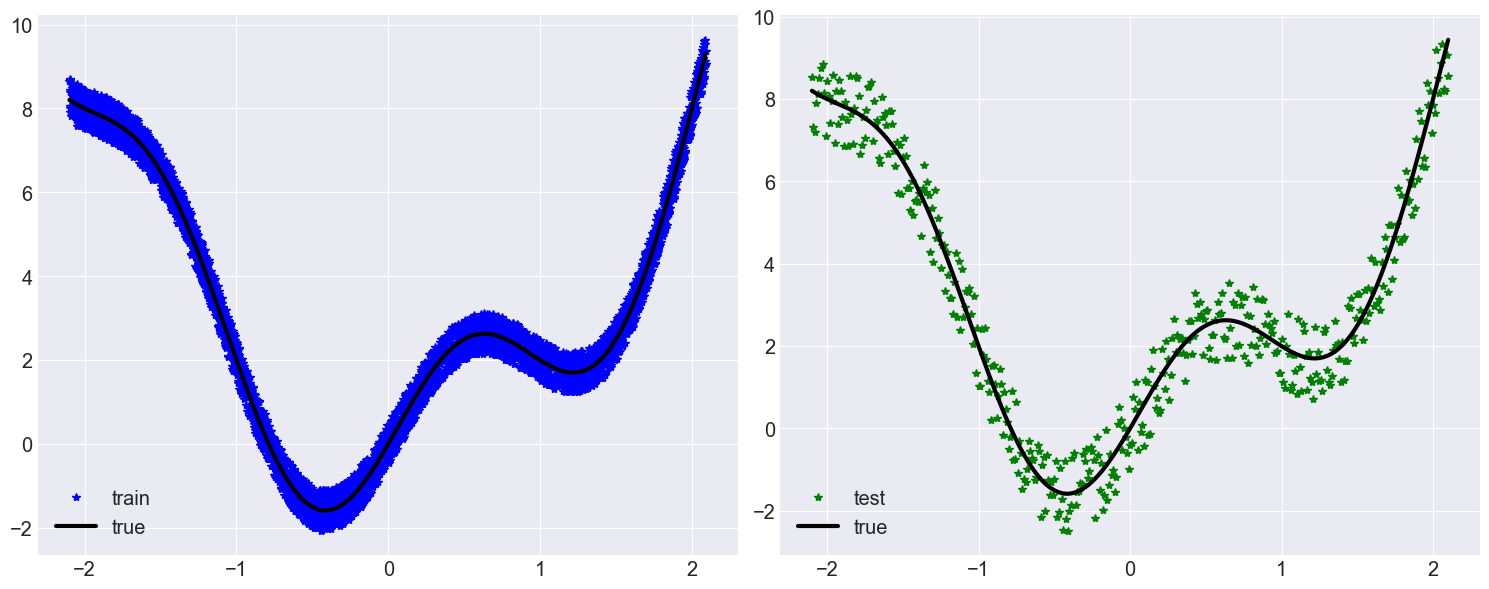

In [8]:
fig, axes = plt.subplots(1,2)
axes[0].plot(X_train, y_train, 'b*', label='train')
axes[0].plot(X_train, y_true, 'k', lw=3, label='true')
axes[0].legend(loc='best')

axes[1].plot(X_test, y_test, 'g*', label='test')
axes[1].plot(X_test, y_true_test, 'k', lw=3, label='true')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

In [9]:
type(X_train), type(X_test), type(y_train), type(y_test)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray)

Converting to Datasets

In [10]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) # a we are passing rows of data thats why slices. it is creating dataset for us
test_ds = tf.data.Dataset.from_tensor_slices((X_test,y_test))


In [11]:
train_ds = train_ds.shuffle(buffer_size=X_train.shape[0]).batch(batch_size=BATCH_SIZE) # shuffle and create batches
test_ds = test_ds.shuffle(buffer_size=X_test.shape[0]).batch(batch_size=BATCH_SIZE)

In [12]:
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE) #autotune to match with harware configuration w.r.t memory available
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


In [13]:
next(iter(train_ds))

(<tf.Tensor: shape=(16,), dtype=float64, numpy=
 array([-1.393,  0.162, -0.761,  1.342,  1.507, -1.675,  0.928,  0.755,
        -0.176, -1.284, -1.391, -0.142, -0.158, -1.66 , -0.407,  1.505])>,
 <tf.Tensor: shape=(16,), dtype=float64, numpy=
 array([ 6.09721033,  0.69522667, -0.19884279,  1.81330547,  2.2227347 ,
         7.25791141,  1.75014018,  2.64985572, -1.46632702,  4.78485306,
         5.96409005, -0.74271343, -0.75702998,  7.38323271, -1.10670729,
         2.9093939 ])>)

In [14]:
for features, labels in train_ds.take(5):
    print(features.shape, labels.shape)

(16,) (16,)
(16,) (16,)
(16,) (16,)
(16,) (16,)
(16,) (16,)


Defining the model using functional API

In [15]:
num_features = 1 # 1 feature
# initializer = tf.keras.initializers.HeUniform(seed=RANDOM_STATE)

input_layer = tf.keras.Input(shape=(1,))

hidden_layer = tf.keras.layers.Dense(512, activation='relu')(input_layer)
hidden_layer = tf.keras.layers.Dense(256, activation='relu')(hidden_layer)
output_layer = tf.keras.layers.Dense(1)(hidden_layer)

model = tf.keras.Model(inputs=input_layer, outputs=output_layer)
print(model)
model.summary()

<Functional name=functional, built=True>


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,609 (518.00 KB)

 Trainable params: 132,609 (518.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
loss_fn = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA)
metrics = tf.keras.metrics.MeanAbsoluteError()

model.compile(optimizer=optimizer, loss=loss_fn, metrics=[metrics])

In [17]:
# CALLBACKS

# Creates TensorBoard callback for visualization of training metrics
tb_callback = tf.keras.callbacks.TensorBoard(
    log_dir='logs'
)

# Stops training early if validation loss stops improving to prevent overfitting
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    verbose=1,
    restore_best_weights=True  # Fixed typo: restore_best_weight -> restore_best_weights
)

# Defines file path for saving model checkpoints
chkpt_filepath = './best_yet.keras'

# Saves model weights when validation loss improves to keep best performing version
chkpt_callback = tf.keras.callbacks.ModelCheckpoint(
    chkpt_filepath,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch',
    initial_value_threshold=None,
)

# Reduces learning rate when validation loss plateaus to help convergence
reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(  # Fixed variable name conflict
    monitor='val_loss',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    verbose=1,
    mode='auto',
    min_delta=0.0001,
    cooldown=0,
    min_lr=MIN_LR,
)

In [18]:
hist = model.fit(train_ds, validation_data=test_ds, 
                    epochs=EPOCHS, callbacks=[
                        # tb_callback, 
                        # chkpt_callback, 
                        reduce_lr_callback, es_callback])


Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.1875 - mean_absolute_error: 1.0944 - val_loss: 1.2334 - val_mean_absolute_error: 0.8706 - learning_rate: 0.0010
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7137 - mean_absolute_error: 0.6396 - val_loss: 0.7895 - val_mean_absolute_error: 0.7223 - learning_rate: 0.0010
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3323 - mean_absolute_error: 0.4527 - val_loss: 0.4908 - val_mean_absolute_error: 0.5842 - learning_rate: 0.0010
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1586 - mean_absolute_error: 0.3240 - val_loss: 0.4124 - val_mean_absolute_error: 0.5462 - learning_rate: 0.0010
Epoch 5/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1244 - mean_absolute_error: 0.2911 - val_loss: 0.4036 - val_mean_absolute_error: 0.5390 - learning_rate: 0.0010
Epoch 6/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1146 - mean_absolute_error: 0.2809 - val_loss: 0.4033 - val_me

In [22]:
hist.history.keys()

dict_keys(['loss', 'mean_absolute_error', 'val_loss', 'val_mean_absolute_error', 'learning_rate'])

In [31]:
hist_df = pd.DataFrame({
    'epoch':range(EPOCHS),
    'loss':hist.history['loss'],
    'test_loss':hist.history['val_loss'],
    'mae':hist.history['mean_absolute_error'],
    'test_mae':hist.history['val_mean_absolute_error']
})



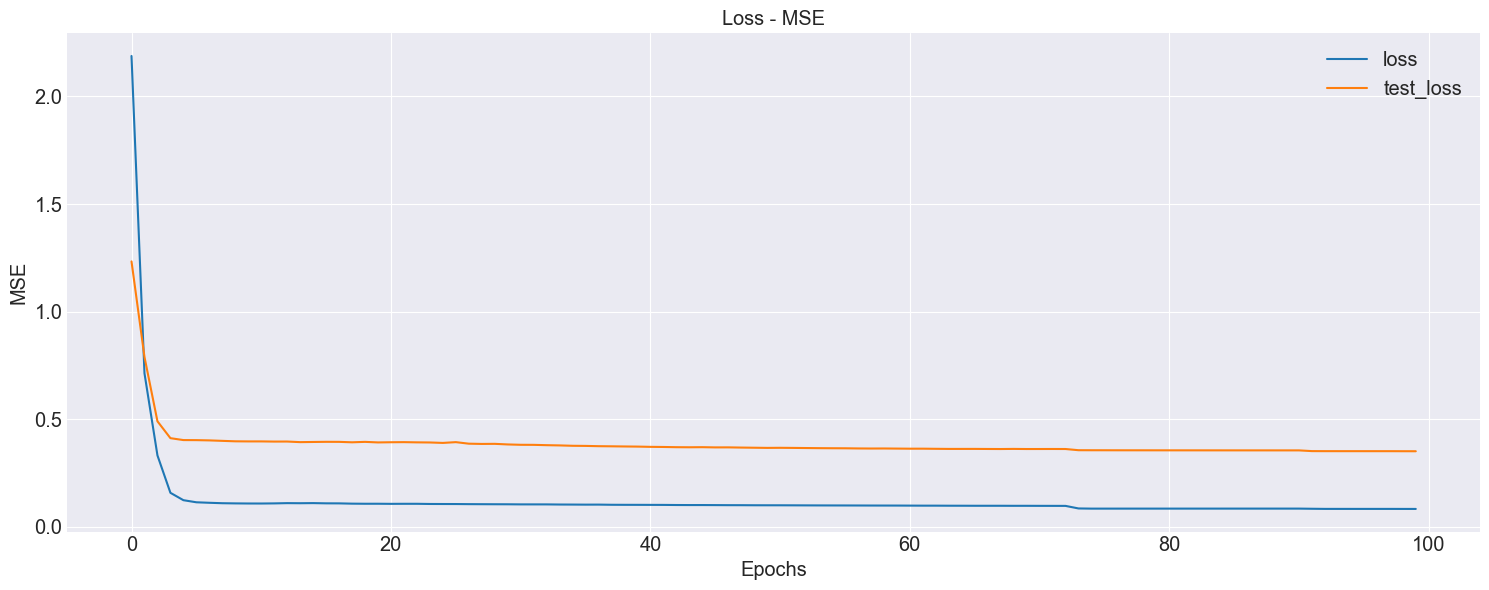

In [38]:
hist_df.plot(y=['loss', 'test_loss'])
plt.ylabel('MSE')
plt.xlabel('Epochs')
plt.title('Loss - MSE')
plt.tight_layout()


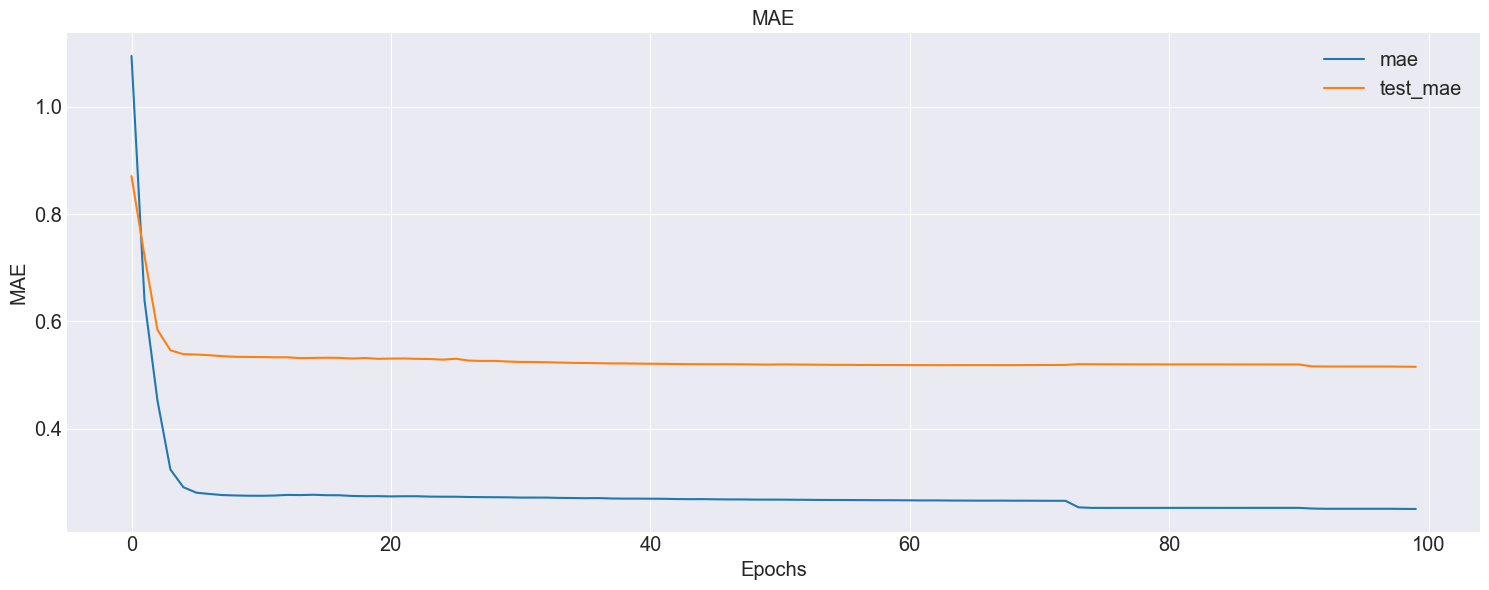

In [39]:
hist_df.plot(y=['mae', 'test_mae'])
plt.ylabel('MAE')
plt.xlabel('Epochs')
plt.title('MAE')
plt.tight_layout()

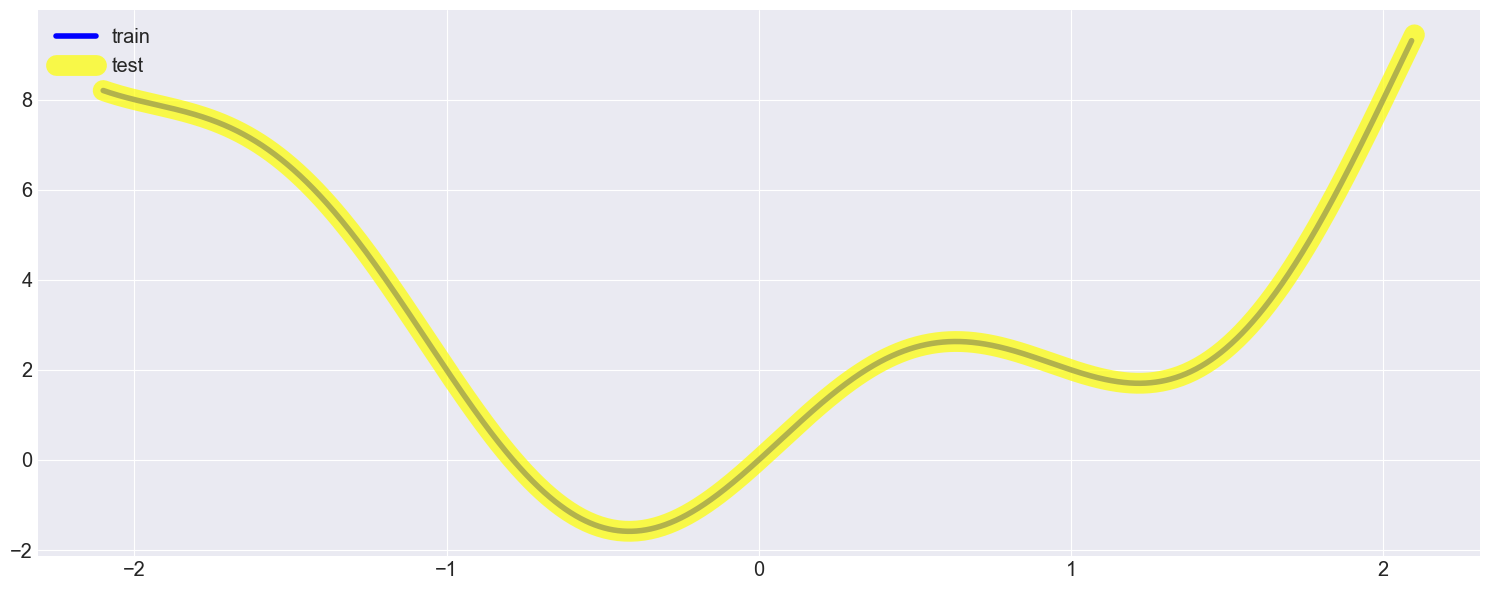

In [60]:
plt.plot(X_train, y_true, lw=4, c='b', label='train')
plt.plot(X_test, y_true_test, lw=15, c='yellow', alpha=0.7, label='test')
plt.legend()
plt.tight_layout()

In [73]:
y_pred = model(X_train).numpy()
y_pred_test = model(X_test).numpy()

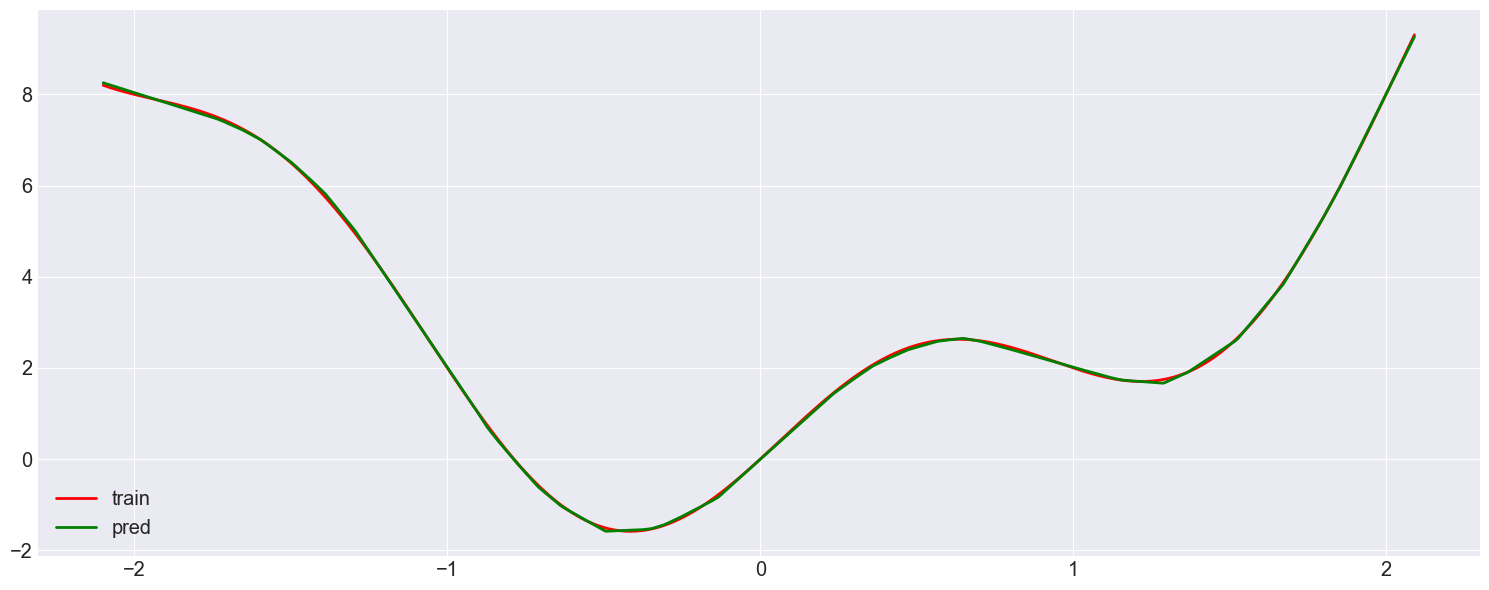

In [93]:
plt.plot(X_train, y_true, lw=2, c='r', label='train')
plt.plot(X_train, y_pred, lw=2, c='g', label='pred')
plt.legend()
plt.tight_layout()

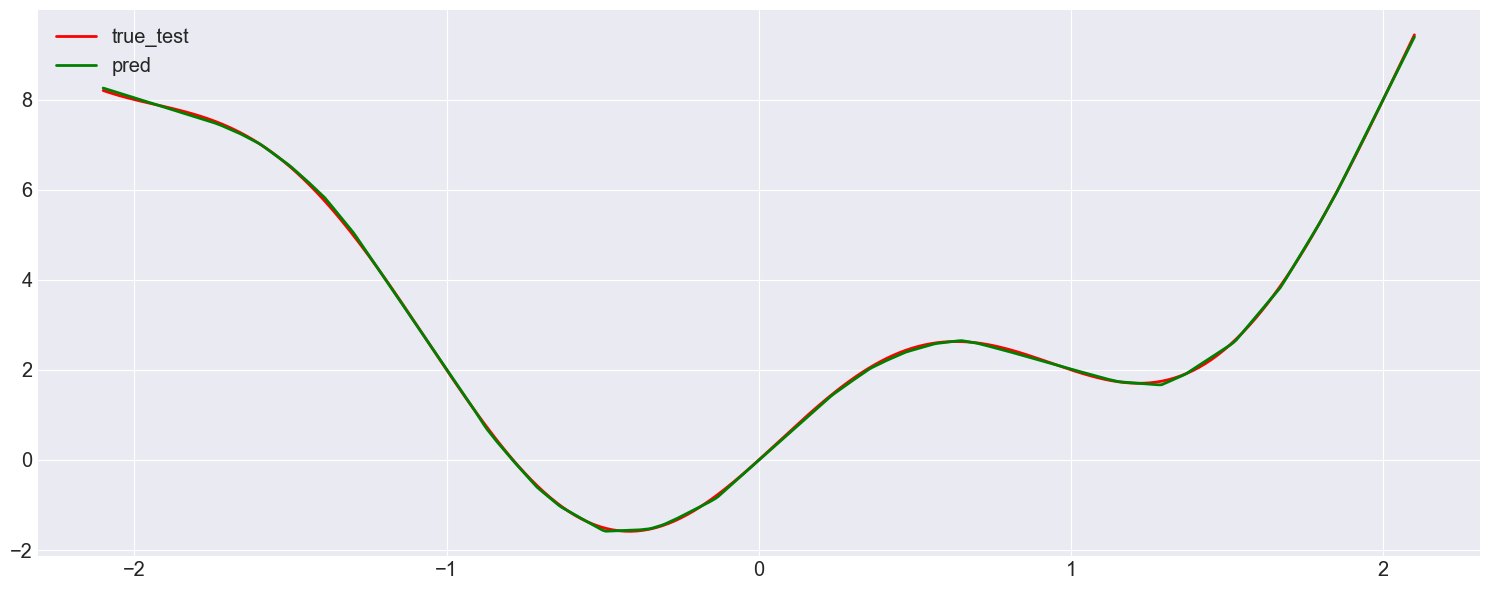

In [105]:
plt.plot(X_test, y_true_test, lw=2, c='r', label='true_test')
plt.plot(X_test, y_pred_test, lw=2, c='g', label='pred')
plt.legend()
plt.tight_layout()

In [85]:
train_df = pd.DataFrame({
    'y_true':y_true,
    'y_train':y_train,
    'pred':y_pred[:, 0]
})
print(train_df.head())

test_df = pd.DataFrame({
    'y_true_test':y_true_test,
    'y_test':y_test,
    'pred':y_pred_test[:, 0]
})
test_df.head()

     y_true   y_train      pred
0  8.201966  8.661983  8.256429
1  8.199547  8.399059  8.254260
2  8.197137  8.697005  8.252091
3  8.194738  7.914805  8.249922
4  8.192349  8.053405  8.247753


,y_true_test,y_test,pred
0,8.201966,8.539487,8.256429
1,8.178218,7.328536,8.234739
2,8.155420,7.193551,8.213049
3,8.133514,7.915680,8.191359
4,8.112437,8.124319,8.169670
